# 🎓 Student Grade Prediction — ML Project
**Target:** G3 (Final Grade) | **Models:** Linear Regression · Random Forest · SVR . XGBOOST

##**📦 Import Libiraries**

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

##**📂 Load Data & 🔧 Preprocessing & 🔍 EDA**

In [67]:
df=pd.read_csv('student_data.csv')
pd.set_option('display.max_columns', None)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [69]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [70]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10


In [71]:
df.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.116456,0.473418,16.696203,0.777215,0.288608,0.896203,2.749367,2.521519,2.169620,2.281013,1.255696,0.853165,1.448101,2.035443,0.334177,0.129114,0.612658,0.458228,0.508861,0.794937,0.949367,0.832911,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,0.321177,0.499926,1.276043,0.416643,0.453690,0.305384,1.094735,1.088201,1.227473,0.863542,1.208236,0.536684,0.697505,0.839240,0.743651,0.335751,0.487761,0.498884,0.500555,0.404260,0.219525,0.373528,0.472300,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,0.000000,16.000000,1.000000,0.000000,1.000000,2.000000,2.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,0.000000,0.000000,17.000000,1.000000,0.000000,1.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,0.000000,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,3.000000,3.000000,3.000000,1.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [72]:
df.duplicated().sum()

np.int64(0)

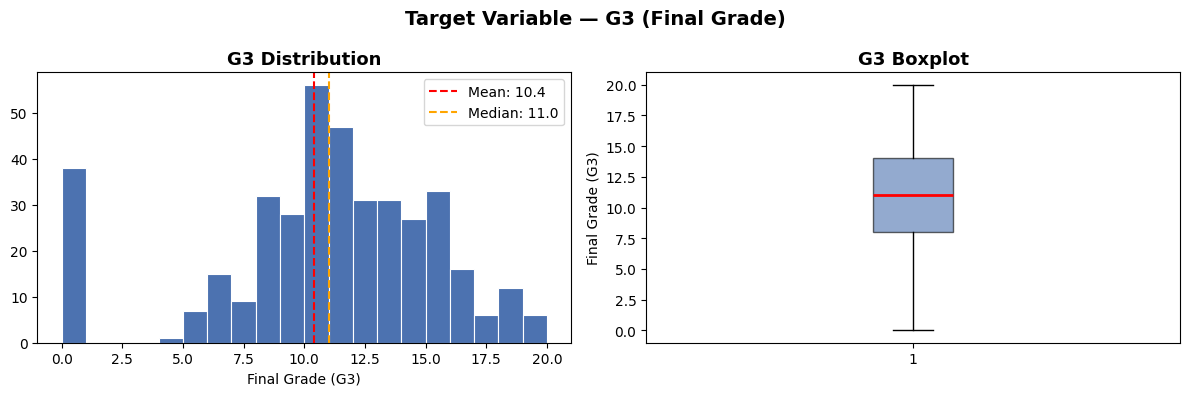

Mean   : 10.42
Median : 11.00
Std    : 4.58
Min    : 0
Max    : 20


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['G3'], bins=20, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['G3'].mean(), color='red', linestyle='--', label=f"Mean: {df['G3'].mean():.1f}")
axes[0].axvline(df['G3'].median(), color='orange', linestyle='--', label=f"Median: {df['G3'].median():.1f}")
axes[0].set_title('G3 Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Grade (G3)')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['G3'], patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('G3 Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Final Grade (G3)')

plt.suptitle('Target Variable — G3 (Final Grade)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean   : {df['G3'].mean():.2f}")
print(f"Median : {df['G3'].median():.2f}")
print(f"Std    : {df['G3'].std():.2f}")
print(f"Min    : {df['G3'].min()}")
print(f"Max    : {df['G3'].max()}")

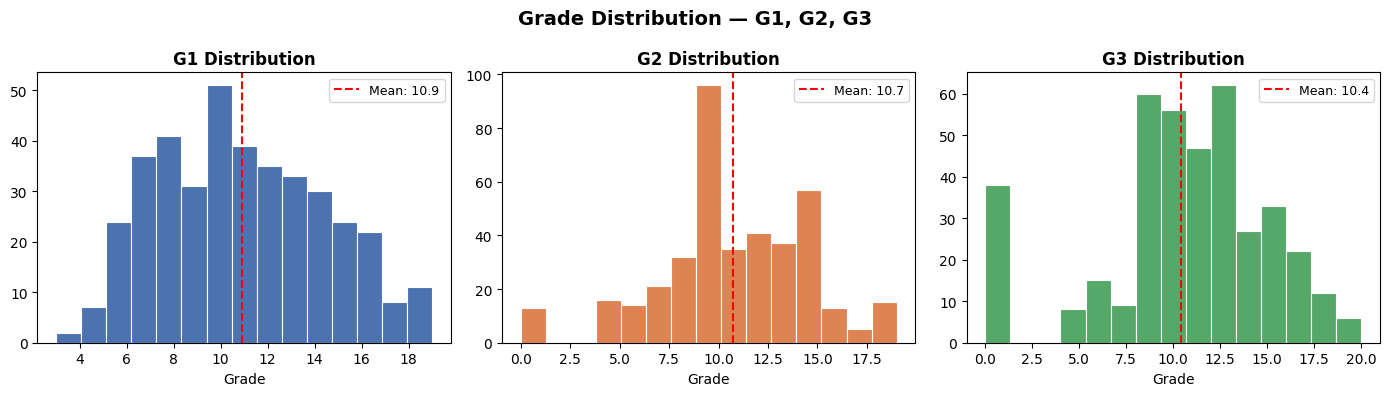

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, color in zip(axes, ['G1', 'G2', 'G3'], colors):
    ax.hist(df[col], bins=15, color=color, edgecolor='white', linewidth=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Grade')
    ax.legend(fontsize=9)

plt.suptitle('Grade Distribution — G1, G2, G3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

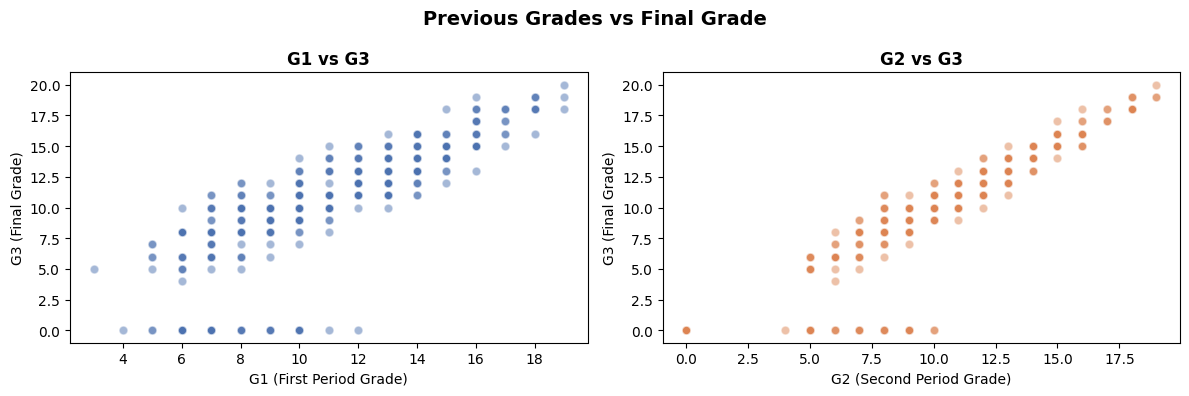

In [75]:
# Scatter: G1 vs G3 and G2 vs G3
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['G1'], df['G3'], alpha=0.5, color='#4C72B0', edgecolors='white', s=40)
axes[0].set_xlabel('G1 (First Period Grade)')
axes[0].set_ylabel('G3 (Final Grade)')
axes[0].set_title('G1 vs G3', fontsize=12, fontweight='bold')

axes[1].scatter(df['G2'], df['G3'], alpha=0.5, color='#DD8452', edgecolors='white', s=40)
axes[1].set_xlabel('G2 (Second Period Grade)')
axes[1].set_ylabel('G3 (Final Grade)')
axes[1].set_title('G2 vs G3', fontsize=12, fontweight='bold')

plt.suptitle('Previous Grades vs Final Grade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_40802/3587823756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='internet', y='G3', data=df, palette=['#C44E52','#55A868'], ax=axes[0])
/tmp/ipykernel_40802/3587823756.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='higher', y='G3', data=df, palette=['#C44E52','#55A868'], ax=axes[1])


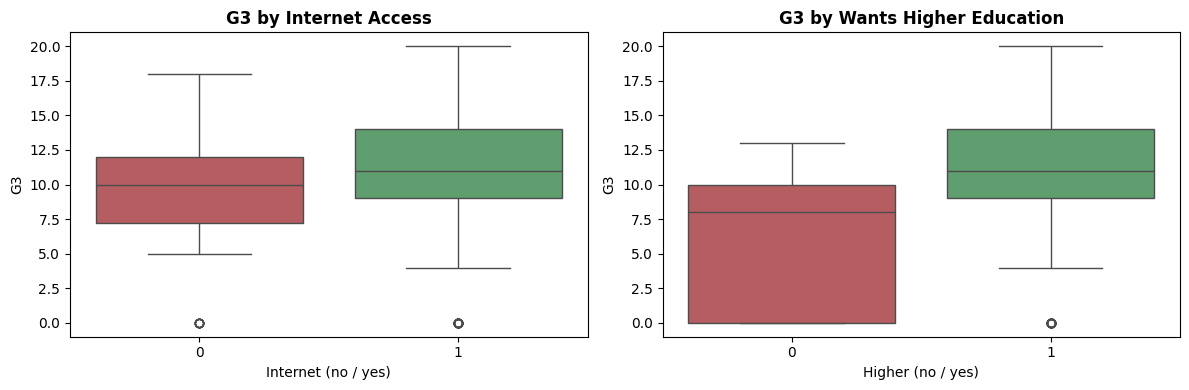

In [76]:
# G3 by Internet & Higher Education
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='internet', y='G3', data=df, palette=['#C44E52','#55A868'], ax=axes[0])
axes[0].set_title('G3 by Internet Access', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Internet (no / yes)')

sns.boxplot(x='higher', y='G3', data=df, palette=['#C44E52','#55A868'], ax=axes[1])
axes[1].set_title('G3 by Wants Higher Education', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Higher (no / yes)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_40802/298419348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='failures', y='G3', data=df, palette='coolwarm')


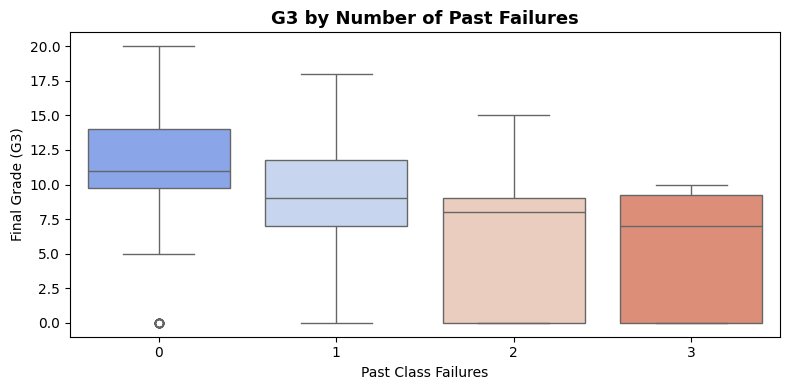

In [77]:
# G3 by Failures
plt.figure(figsize=(8, 4))
sns.boxplot(x='failures', y='G3', data=df, palette='coolwarm')
plt.title('G3 by Number of Past Failures', fontsize=13, fontweight='bold')
plt.xlabel('Past Class Failures')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_40802/2441531017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')


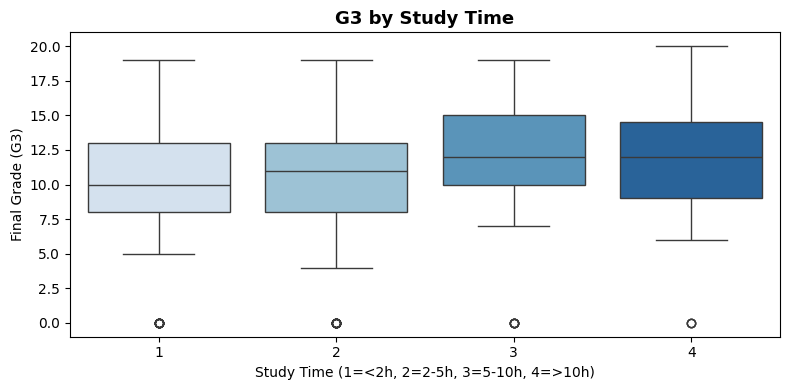

In [78]:
# G3 by Study Time
plt.figure(figsize=(8, 4))
sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')
plt.title('G3 by Study Time', fontsize=13, fontweight='bold')
plt.xlabel('Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

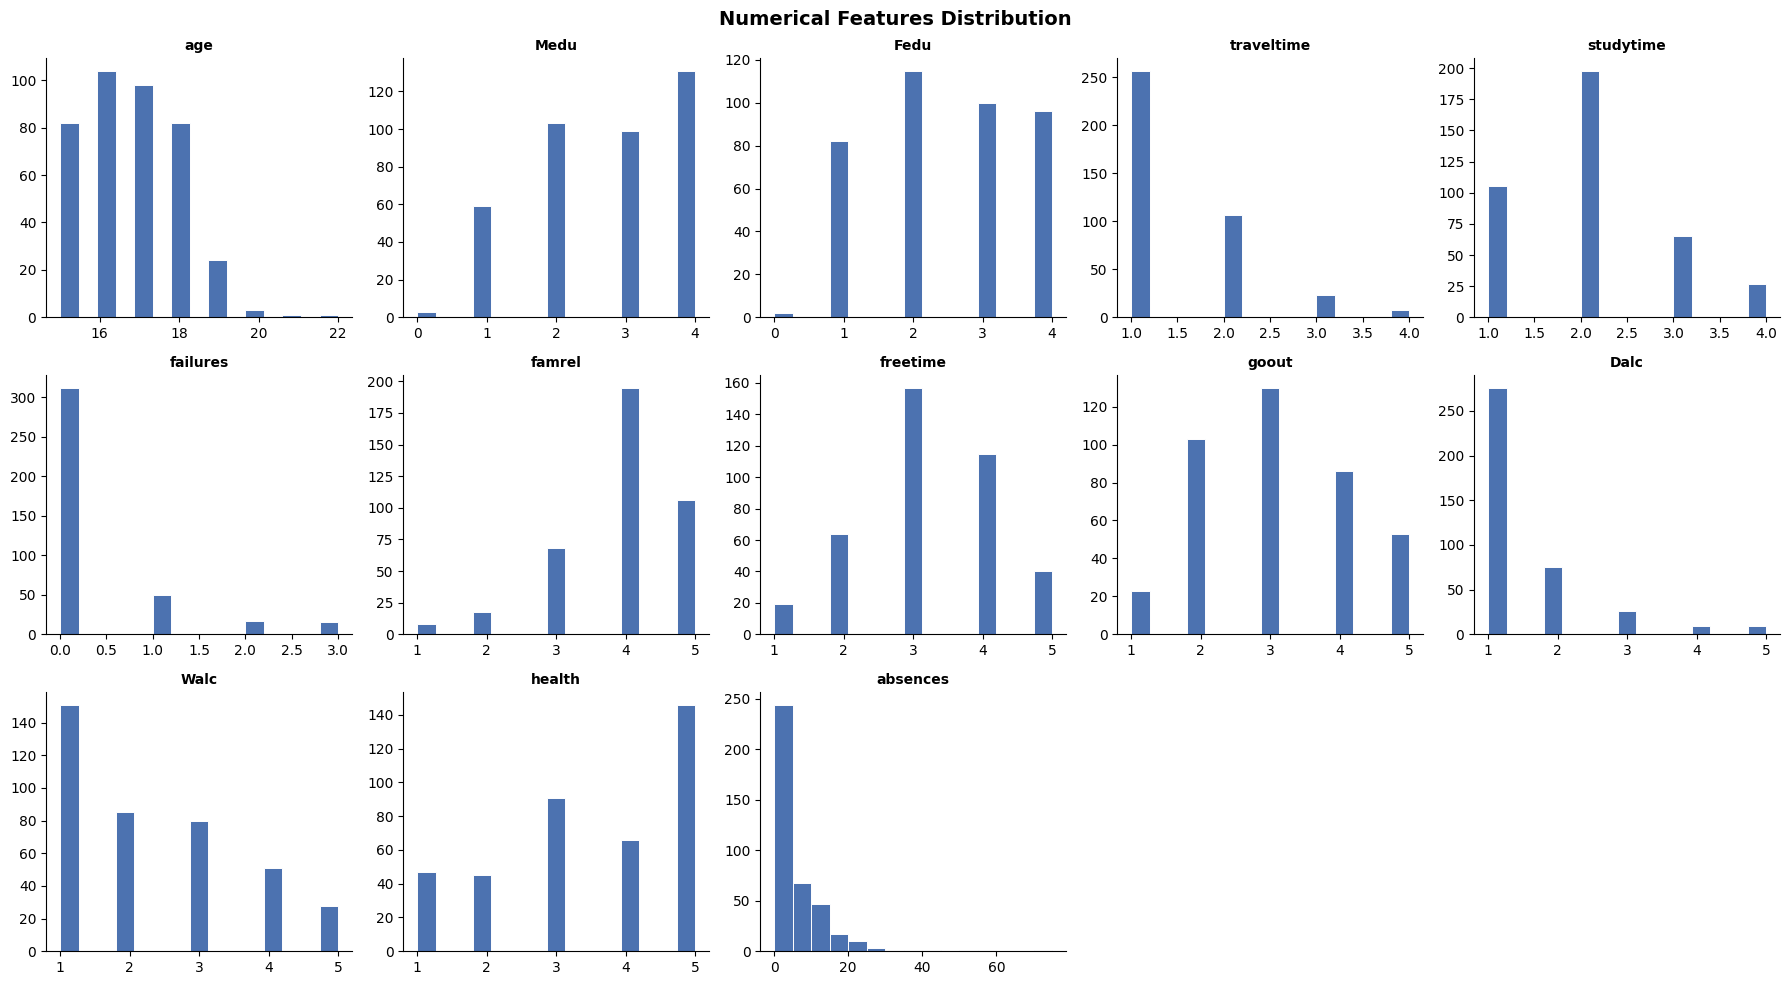

In [79]:
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
            'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=15, color='#4C72B0', edgecolor='white', linewidth=0.7)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].spines[['top','right']].set_visible(False)

# Hide unused axes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

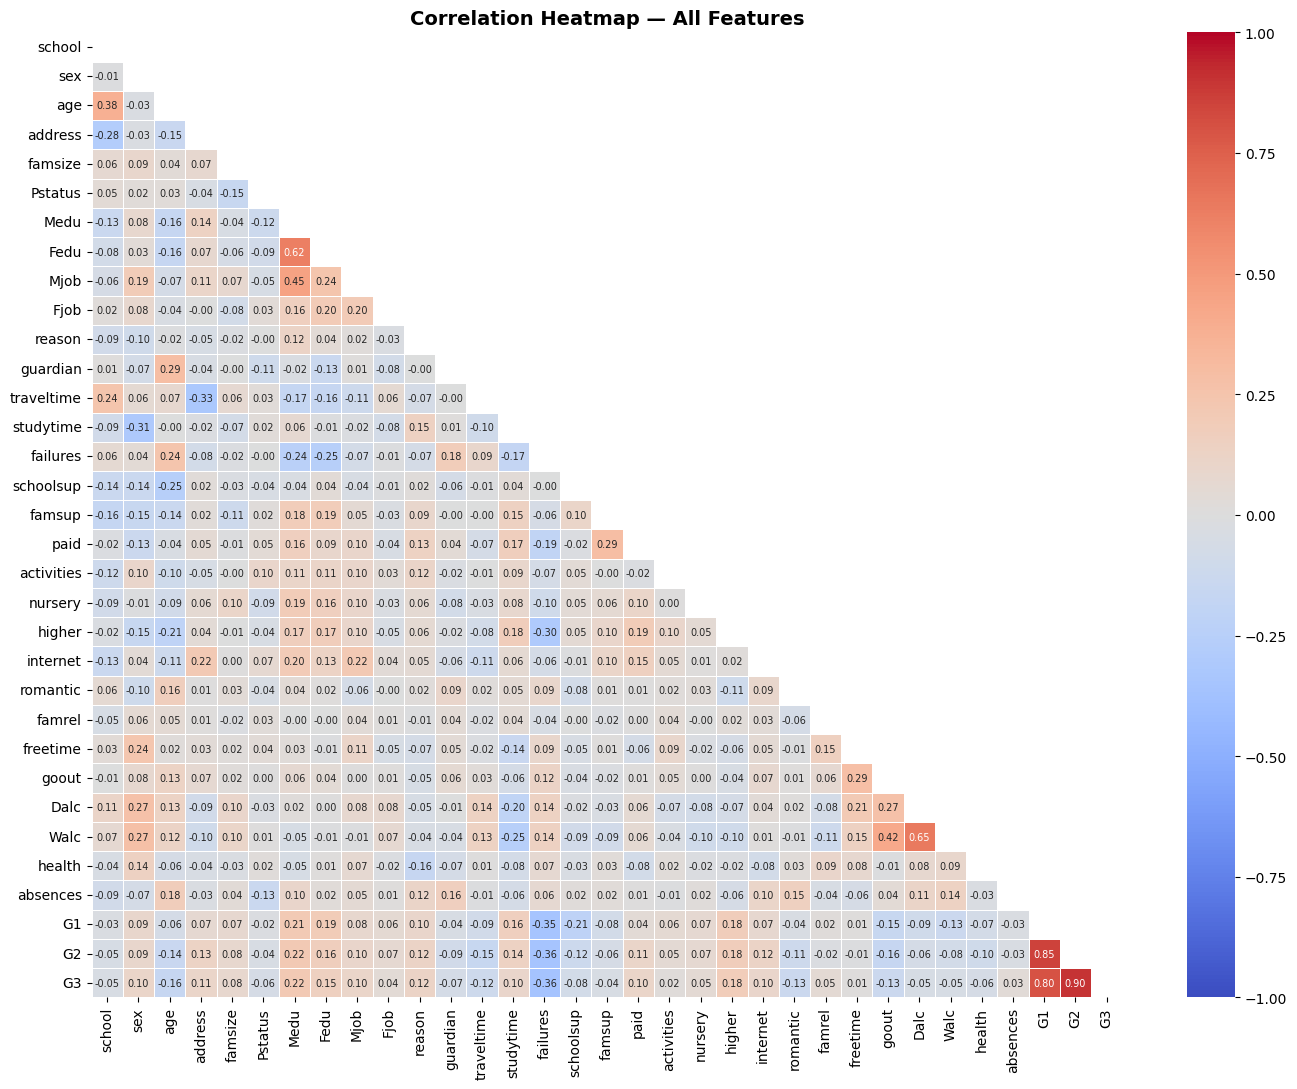

In [80]:
plt.figure(figsize=(14, 11))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

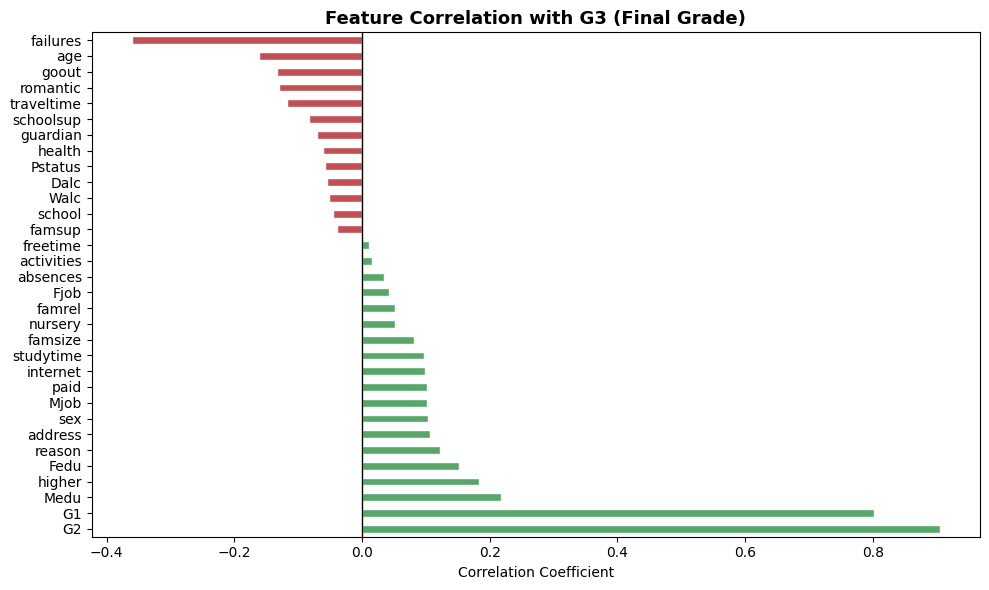

Top Positive Correlations with G3:
G2        0.904868
G1        0.801468
Medu      0.217147
higher    0.182465
Fedu      0.152457
Name: G3, dtype: float64

Top Negative Correlations with G3:
traveltime   -0.117142
romantic     -0.129970
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [81]:
# Top correlations with G3
g3_corr = df.corr()['G3'].drop('G3').sort_values(ascending=False)

colors = ['#55A868' if v > 0 else '#C44E52' for v in g3_corr.values]

plt.figure(figsize=(10, 6))
g3_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=1)
plt.title('Feature Correlation with G3 (Final Grade)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('Top Positive Correlations with G3:')
print(g3_corr.head(5))
print('\nTop Negative Correlations with G3:')
print(g3_corr.tail(5))

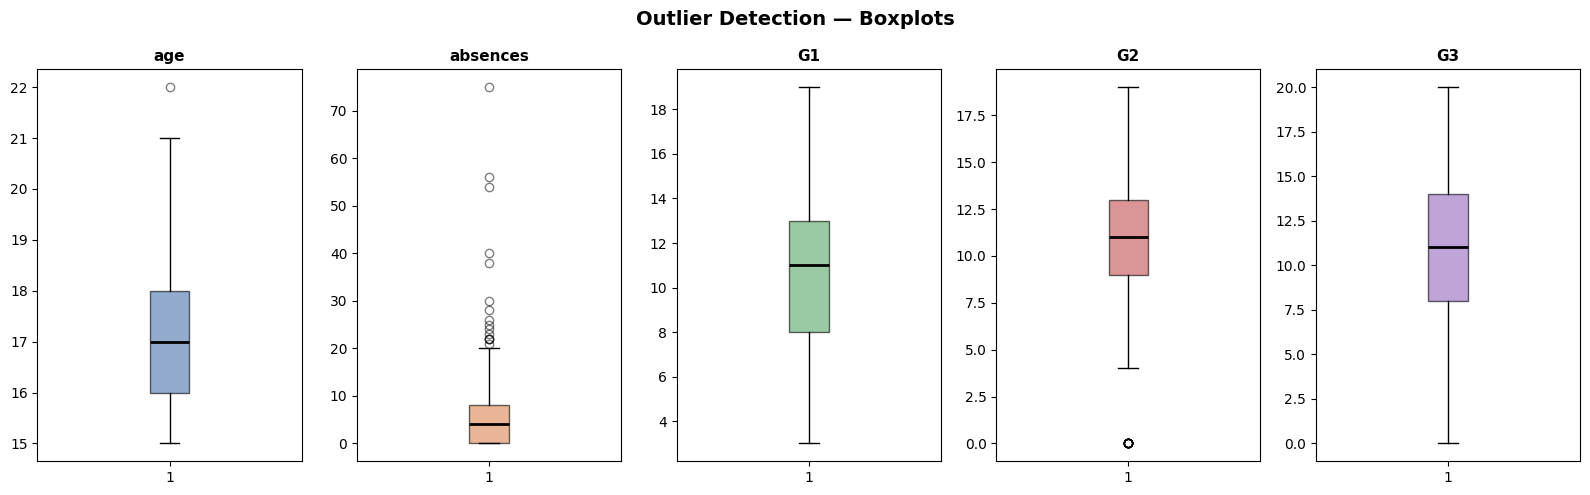

In [82]:
outlier_cols = ['age', 'absences', 'G1', 'G2', 'G3']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']

for ax, col, color in zip(axes, outlier_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', color=color, alpha=0.5))
    ax.set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##**Data Spliting & Feature Scaling**

In [83]:
X = df.drop(columns=['G3'])
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

##**Models**

##**🔵 Linear Regression**

In [84]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_r2   = r2_score(y_test, lr_pred)

print('── Linear Regression ──')
print(f'RMSE : {lr_rmse:.3f}')
print(f'MAE  : {lr_mae:.3f}')
print(f'R²   : {lr_r2:.3f}')

── Linear Regression ──
RMSE : 2.243
MAE  : 1.495
R²   : 0.755


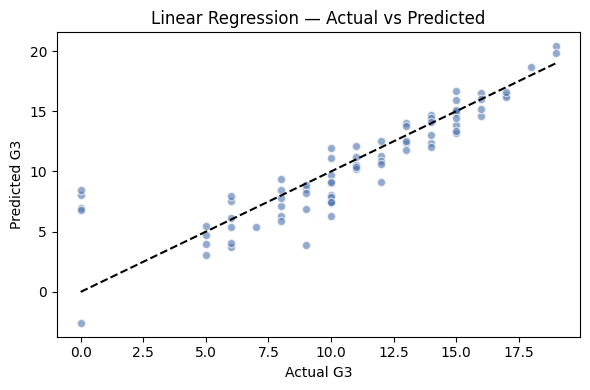

In [85]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, lr_pred, alpha=0.6, color='#4C72B0', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Linear Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

##**🟠 Random Forest Regressor**

In [86]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print('── Random Forest ──')
print(f'RMSE : {rf_rmse:.3f}')
print(f'MAE  : {rf_mae:.3f}')
print(f'R²   : {rf_r2:.3f}')

── Random Forest ──
RMSE : 1.902
MAE  : 1.106
R²   : 0.824


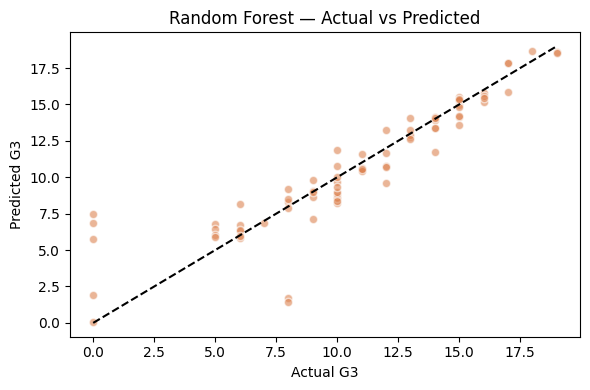

In [87]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, rf_pred, alpha=0.6, color='#DD8452', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Random Forest — Actual vs Predicted')
plt.tight_layout()
plt.show()

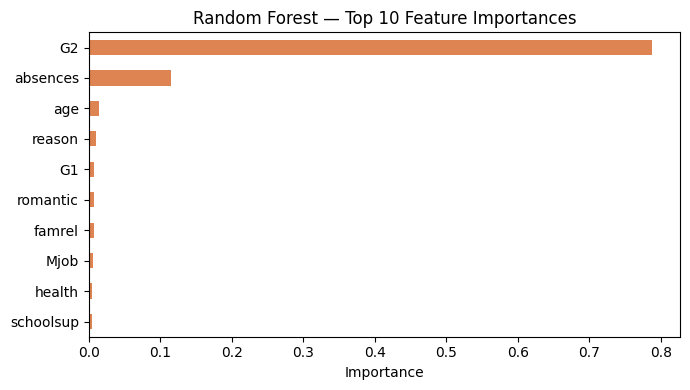

In [88]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(7,4))
feat_imp[::-1].plot(kind='barh', color='#DD8452')
plt.title('Random Forest — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

##**🟢 Support Vector Regressor (SVR)**

In [89]:
svr = SVR(kernel='rbf', C=10, epsilon=0.5)
svr.fit(X_train_sc, y_train)
svr_pred = svr.predict(X_test_sc)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_mae  = mean_absolute_error(y_test, svr_pred)
svr_r2   = r2_score(y_test, svr_pred)

print('── SVR ──')
print(f'RMSE : {svr_rmse:.3f}')
print(f'MAE  : {svr_mae:.3f}')
print(f'R²   : {svr_r2:.3f}')

── SVR ──
RMSE : 2.545
MAE  : 1.849
R²   : 0.684


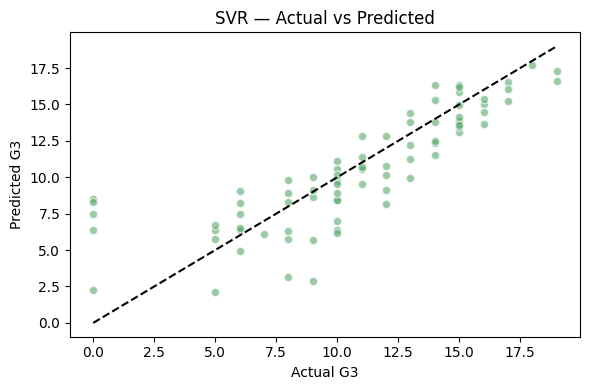

In [90]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, svr_pred, alpha=0.6, color='#55A868', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('SVR — Actual vs Predicted')
plt.tight_layout()
plt.show()

##**🔴 XGBoost Regressor**

In [91]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_r2   = r2_score(y_test, xgb_pred)

print('── XGBoost ──')
print(f'RMSE : {xgb_rmse:.3f}')
print(f'MAE  : {xgb_mae:.3f}')
print(f'R²   : {xgb_r2:.3f}')

── XGBoost ──
RMSE : 2.065
MAE  : 1.232
R²   : 0.792


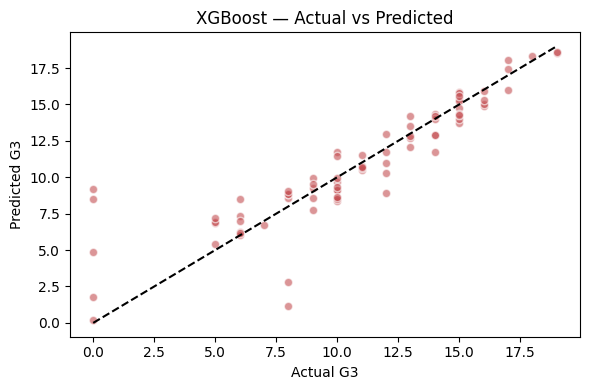

In [92]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, xgb_pred, alpha=0.6, color='#C44E52', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('XGBoost — Actual vs Predicted')
plt.tight_layout()
plt.show()

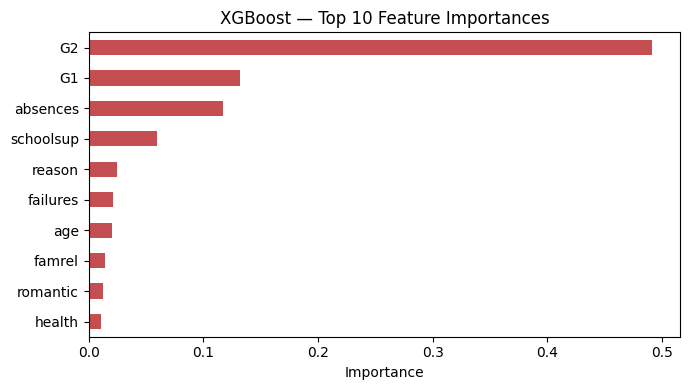

In [93]:
xgb_feat_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(7,4))
xgb_feat_imp[::-1].plot(kind='barh', color='#C44E52')
plt.title('XGBoost — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

##**📊 Model Comparison**

In [94]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR', 'XGBoost'],
    'RMSE' : [lr_rmse, rf_rmse, svr_rmse, xgb_rmse],
    'MAE'  : [lr_mae,  rf_mae,  svr_mae,  xgb_mae],
    'R²'   : [lr_r2,   rf_r2,   svr_r2,   xgb_r2]
})
comparison = comparison.set_index('Model').round(3)
print(comparison)
comparison

                    RMSE    MAE     R²
Model                                 
Linear Regression  2.243  1.495  0.755
Random Forest      1.902  1.106  0.824
SVR                2.545  1.849  0.684
XGBoost            2.065  1.232  0.792


,RMSE,MAE,R²
Model,,,
Linear Regression,2.243,1.495,0.755
Random Forest,1.902,1.106,0.824
SVR,2.545,1.849,0.684
XGBoost,2.065,1.232,0.792


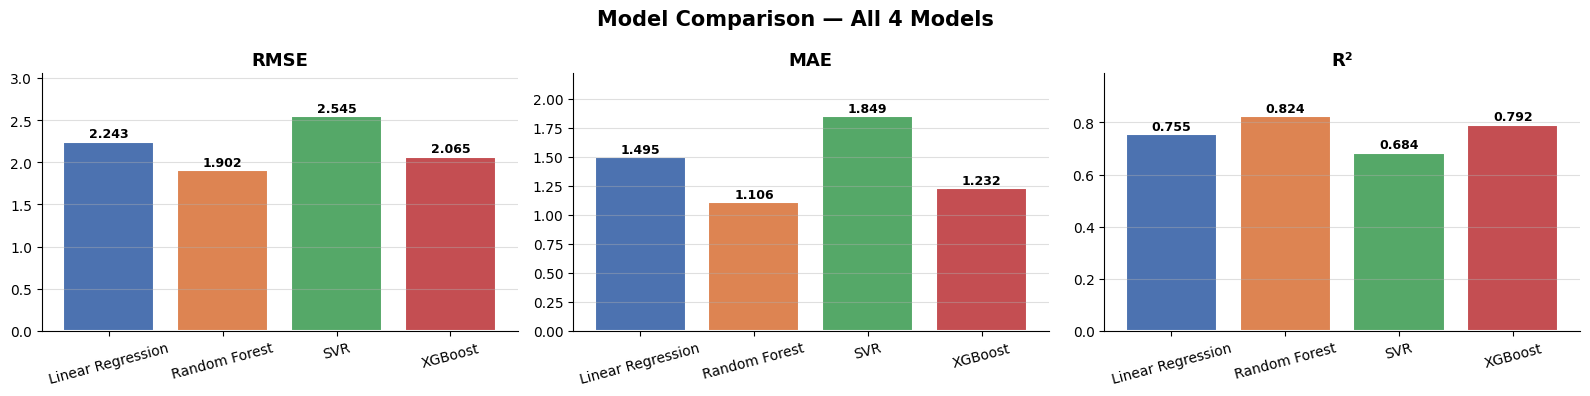

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
models_names = ['Linear Regression', 'Random Forest', 'SVR', 'XGBoost']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    vals = comparison[metric].values
    bars = ax.bar(models_names, vals, color=colors, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Model Comparison — All 4 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()